# Image Recognition & Segmentation

Two-stage pipeline that improves color extraction by first classifying product type, then applying type-conditional color extraction. Includes evaluation against ground truth and an active learning cycle to improve the classifier.

**Stage 1: Classifier:** ResNet-18 fine-tuned on seven container/presentation types: `bullet`, `liquid`, `closed`, `swatch`, `pencil`, `lips`, `unclassifiable`. `pencil` and `lips` were introduced in a later annotation round; `lips` (18 examples) is now the scarcer of the two after `pencil` grew to 28 in the pencil/crayon keyword-oversampling round. `unclassifiable` merges two dead-end cases -- a fully sealed container with no color visible, and a photo showing multiple products / a palette / not a single product shot -- since both get the same downstream treatment (no extraction).

**Stage 2: Segmenters:** U-Nets (ResNet-18 encoder, ImageNet pretrained) trained per class:
- `bullet` + `liquid` + `pencil` → `unet_segmenter.pth`
- `closed` (transparent containers) → `unet_segmenter_other.pth`
- `swatch` → `unet_swatch.pth`
- `lips` → `unet_lips.pth` -- warm-started from the combined segmenter like `closed` was; trained on 12 of 16 de-duplicated examples with a fixed 4-image held-out validation split (started at 3 examples with no validation possible at all)
- `unclassifiable` has no segmenter -- there's nothing to extract from either underlying case.

**Routing logic:**
- `bullet` / `liquid` / `pencil` → U-Net mask → median LAB from masked pixels
- `closed` → separate U-Net mask → dominant cluster LAB from masked pixels
- `swatch` → U-Net mask → median LAB from masked pixels
- `lips` → U-Net mask → median LAB from masked pixels
- `unclassifiable` → no extraction (trained class, not a confidence-threshold guess)
- confidence < 0.6 for any prediction → no extraction, same as `unclassifiable` -- a secondary safety net for images that don't even resemble the trained `unclassifiable` examples

**Evaluation:** Delta E CIE 2000 vs. ground-truth LAB per container type; five extraction strategies compared (mean, median, trimmed mean, dominant cluster, shadow-filtered) to select the best per type.

**Active learning:** classifier uncertainty is scored on out-of-training images; low-confidence predictions are exported as an annotation queue, corrected labels are merged back, and Stage 1 is fine-tuned on the expanded dataset. Section 7 does the same for segmentation masks, covering `pencil` and `lips`.

**Training history:** Phase 1 trained the classifier on the original annotation set. Section 6's active-learning loop was run for real once: 48 low-confidence pool images were reviewed and corrected (`closed` 17, `swatch` 16, `liquid` 9, `bullet` 6), expanding train/val from 162/36 to 204/42 and lifting routing accuracy on the training/val set from 99.0% to 100.0% (`bullet`: 96% -> 100%). Rather than keep running that incremental correct-and-finetune cycle, later rounds redesigned the training set directly instead: notebook 05's Rounds 3-5 oversampled `pencil`/`lips`/`unclassifiable` and grew `annotations_combined.csv` from 297 to 379 images, and Stage 1 here is retrained from scratch each time on the expanded set. Section 6/7's queue-export cells still run every time and are useful for surfacing new low-confidence candidates, but the "correct labels -> fine-tune" step hasn't been re-exercised since that pivot -- the "No corrected labels yet" fallback and identical before/after numbers seen further down reflect that choice, not a failure.

Evidence from that completed round (commit `f6b44cc`, before the redesign): the pool at the time was almost entirely Chanel Le Rouge Duo (`closed`-container) images predicted as `bullet` at 66-72% confidence -- a real instance of the pattern Section 6's plot below is titled after --

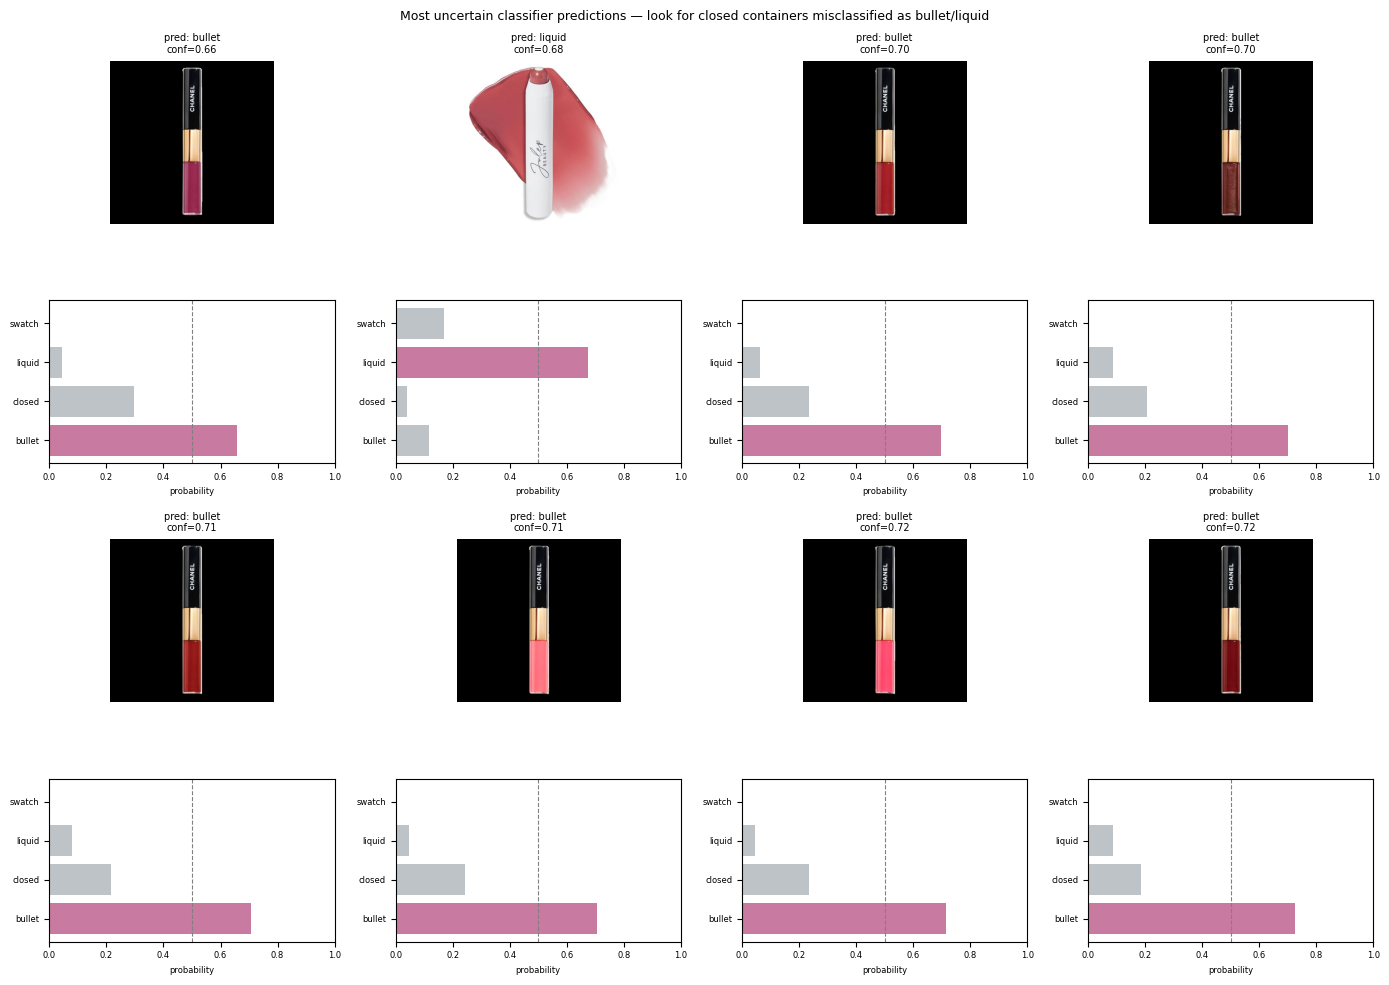

and after reviewing and correcting those 48 labels and fine-tuning, the validation confusion matrix was a clean diagonal (12/12 bullet, 1/1 closed, 9/9 liquid, 20/20 swatch):

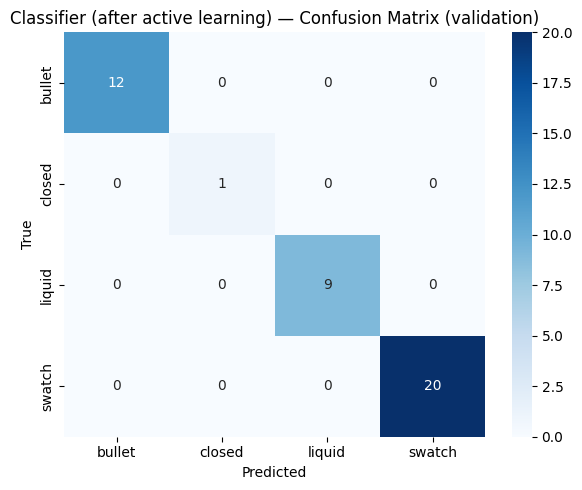

**Inputs:** `data/processed/annotations_combined.csv`, `data/img/annotation_sample/`, `data/img/annotation_sample_closed/`, `data/processed/project-4-at-2026-08-22-23-28-2ae685b5.json`

**Outputs:** `models/resnet18_classifier.pth`, `models/unet_segmenter.pth`, `models/unet_segmenter_other.pth`, `models/unet_swatch.pth`, `models/unet_lips.pth`, `models/resnet18_classifier_al.pth`, `data/annotations/labels.csv`, `data/annotations/masks/`, `data/annotations/active_learning_queue.csv`, `data/annotations/active_learning_seg_queue.csv`

In [1]:
import os
import sys
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from skimage import color as skcolor
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
warnings.filterwarnings('ignore')

SEED = 42

def seed_everything(seed=SEED):
    """Re-seed every RNG this notebook draws from. Called once here and again
    right before each training loop below -- augmentation (SegDatasetAny) uses
    Python's random module, which torch.manual_seed does not cover, and without
    re-seeding per stage, results drift depending on how many random draws
    happened earlier in the run (e.g. whether the 'not used' augmentation
    experiment executed first)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

seed_everything()

BASE = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, BASE)

DATA       = os.path.join(BASE, 'data', 'processed')
IMG        = os.path.join(BASE, 'data', 'img')
ANN_DIR    = os.path.join(BASE, 'data', 'annotations')
MASKS_DIR  = os.path.join(ANN_DIR, 'masks')
MODELS_DIR = os.path.join(BASE, 'models')
IMG_SAMPLE = os.path.join(IMG, 'annotation_sample')
IMG_CLOSED = os.path.join(IMG, 'annotation_sample_closed')
IMG_DIRS   = [IMG_SAMPLE, IMG_CLOSED]

os.makedirs(MASKS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEVICE}  |  seed: {SEED}')

device: mps  |  seed: 42


## 1. Data Preparation

In [2]:
CLASSES = ['bullet', 'closed', 'lips', 'liquid', 'pencil', 'swatch', 'unclassifiable']  # sorted alphabetically
CLF_THRESHOLD = 0.6  # below this confidence for ANY class → no extraction (secondary safety net)

df = pd.read_csv(os.path.join(DATA, 'annotations_combined.csv'))
print(df['label'].value_counts())
print(f'\n{len(df)} annotated images')

label
swatch            127
bullet             83
liquid             60
closed             47
pencil             29
unclassifiable     28
lips               18
Name: count, dtype: int64

392 annotated images


In [3]:
from label_studio_converter.brush import decode_rle as _ls_decode_rle

def find_image(img_name, img_dirs=IMG_DIRS):
    for d in img_dirs:
        p = os.path.join(d, img_name)
        if os.path.exists(p):
            return p
    return None

def decode_rle(rle, height, width):
    """Decode Label Studio brush RLE to a binary mask (H x W, uint8).
    Label Studio encodes brush strokes as RGBA; the mask region is the alpha channel (index 3).
    """
    flat = _ls_decode_rle(rle)           # → length h*w*4, row-major RGBA bytes
    rgba = flat.reshape(height, width, 4)
    return (rgba[:, :, 3] > 0).astype(np.uint8)

In [4]:
import re

def resolve_img_name(img_name):
    """Map a Label Studio img_name to the actual filename on disk.
    When two images shared a base filename, Label Studio appended _XXXXXXX (7 alphanumeric chars)
    before the extension. Strip the suffix to find the real file, but keep the original name for traceability.
    """
    if find_image(img_name) is not None:
        return img_name
    base = re.sub(r'_[A-Za-z0-9]{7}(\.jpg)$', r'\1', img_name)
    if base != img_name and find_image(base) is not None:
        return base
    return None  # unresolvable

df['img_name_disk'] = df['img_name'].apply(resolve_img_name)
found    = df['img_name_disk'].notna().sum()
not_found = df['img_name_disk'].isna().sum()
print(f'{found} images resolved to a file on disk, {not_found} unresolvable')
print(df[['img_name', 'img_name_disk']].head(3))

392 images resolved to a file on disk, 0 unresolvable
                                            img_name  \
0  lipstick__aboutface__paintit_matte_lip_color__...   
1  lipstick__anastasia_beverly_hills__liquid_lips...   
2  lipstick__anastasia_beverly_hills__liquid_lips...   

                                       img_name_disk  
0  lipstick__aboutface__paintit_matte_lip_color__...  
1  lipstick__anastasia_beverly_hills__liquid_lips...  
2  lipstick__anastasia_beverly_hills__liquid_lips...  


In [5]:
# Decode RLE masks from Label Studio JSON → save as PNG in data/annotations/masks/
import glob, hashlib

# Notebook 05's resolve_truncated_name() maps Label Studio's truncated uploads back
# to real catalog names in annotations_combined.csv (df here) -- see that notebook for
# the full story. task_lookup below must resolve raw task names the same way, or masks
# for every renamed image silently fail to match (this happened: 68 masks skipped).
_MASK_CLEAN = os.path.join(IMG, 'original_clean')
_MASK_LS_UPLOAD_ROOT = os.path.expanduser('~/Library/Application Support/label-studio/media/upload')
_MASK_STAGING_DIRS = [
    IMG_SAMPLE,
    IMG_CLOSED,
    os.path.join(IMG, 'annotation_sample_pencil'),
    os.path.join(IMG, 'annotation_sample_lips_notshown'),
    os.path.join(IMG, 'annotation_sample_style'),
    os.path.join(IMG, 'annotation_sample_color_strat'),
]

def _mask_file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

_mask_staging_index_cache = None
def _mask_staging_index():
    global _mask_staging_index_cache
    if _mask_staging_index_cache is None:
        index = {}
        for d in _MASK_STAGING_DIRS:
            if not os.path.isdir(d):
                continue
            for name in os.listdir(d):
                p = os.path.join(d, name)
                if os.path.isfile(p):
                    index.setdefault(_mask_file_hash(p), set()).add(name)
        _mask_staging_index_cache = index
    return _mask_staging_index_cache

def resolve_task_img_name(img_name):
    if os.path.exists(os.path.join(_MASK_CLEAN, img_name)):
        return img_name
    upload_matches = glob.glob(os.path.join(_MASK_LS_UPLOAD_ROOT, '*', f'*-{img_name}'))
    if upload_matches:
        target_hash = _mask_file_hash(upload_matches[0])
        staged = {n for n in _mask_staging_index().get(target_hash, set())
                  if os.path.exists(os.path.join(_MASK_CLEAN, n))}
        if len(staged) == 1:
            return next(iter(staged))
    return img_name  # leave as-is if unresolvable, matching notebook 05's fallback

with open(os.path.join(DATA, 'project-4-at-2026-08-22-23-28-2ae685b5.json')) as f:
    raw = json.load(f)

task_lookup = {}
for task in raw:
    img_name = os.path.basename(task['data']['image'])
    img_name = img_name.split('-', 1)[-1] if '-' in img_name else img_name
    img_name = resolve_task_img_name(img_name)
    ann = task['annotations'][0]
    if not ann['result']:
        continue
    task_lookup[img_name] = ann['result'][0]  # store full result entry (h/w are here, not in ['value'])

saved, skipped = 0, 0
for _, row in df.iterrows():
    stem = os.path.splitext(row['img_name'])[0]
    out_path = os.path.join(MASKS_DIR, stem + '.png')
    if row['img_name'] not in task_lookup:
        skipped += 1
        continue
    entry = task_lookup[row['img_name']]
    rle = entry['value'].get('rle', [])
    h   = entry.get('original_height', 0)
    w   = entry.get('original_width', 0)
    if not rle or not h or not w:
        skipped += 1
        continue
    mask = decode_rle(rle, h, w)
    Image.fromarray(mask * 255).save(out_path)
    saved += 1

print(f'Saved {saved} masks, skipped {skipped}')

Saved 375 masks, skipped 17


In [6]:
# Join with ground-truth LAB values and save data/annotations/labels.csv
products = pd.read_csv(os.path.join(DATA, 'products_with_images.csv'))
gt = products[products['ground_truth_CIELAB'].notna()][['img_name', 'ground_truth_CIELAB']].copy()

# Normalize GT img_names to .jpg — annotation_sample uses original_clean/ which converts everything to .jpg
gt['img_name_disk'] = gt['img_name'].apply(lambda n: os.path.splitext(n)[0] + '.jpg')

def parse_cielab(s):
    arr = np.fromstring(str(s).strip('[]'), sep=' ')
    return pd.Series({'true_L': arr[0], 'true_a': arr[1], 'true_b': arr[2]})

gt = gt.join(gt['ground_truth_CIELAB'].apply(parse_cielab)).drop(columns=['ground_truth_CIELAB', 'img_name'])

# Join on img_name_disk (resolved filename) so suffix-conflict rows match correctly
labels_df = df.merge(gt, on='img_name_disk', how='left')
labels_df['mask_path'] = labels_df['img_name'].apply(
    lambda n: os.path.join(MASKS_DIR, os.path.splitext(n)[0] + '.png')
)
labels_df.to_csv(os.path.join(ANN_DIR, 'labels.csv'), index=False)
print(labels_df[['img_name', 'img_name_disk', 'label', 'true_L']].head())
print(f'\n{labels_df["true_L"].notna().sum()} / {len(labels_df)} images have ground-truth LAB')


                                            img_name  \
0  lipstick__aboutface__paintit_matte_lip_color__...   
1  lipstick__anastasia_beverly_hills__liquid_lips...   
2  lipstick__anastasia_beverly_hills__liquid_lips...   
3  lipstick__anastasia_beverly_hills__matte_lipst...   
4  lipstick__anastasia_beverly_hills__matte_lipst...   

                                       img_name_disk   label     true_L  
0  lipstick__aboutface__paintit_matte_lip_color__...  swatch   2.677718  
1  lipstick__anastasia_beverly_hills__liquid_lips...  swatch  42.008854  
2  lipstick__anastasia_beverly_hills__liquid_lips...  liquid  27.463101  
3  lipstick__anastasia_beverly_hills__matte_lipst...  bullet  57.439487  
4  lipstick__anastasia_beverly_hills__matte_lipst...  swatch  63.296015  

210 / 392 images have ground-truth LAB


Class distribution is unbalanced: swatches make up ~32% of annotations. `lips` (18) is now the scarcest class overall -- the pencil/crayon keyword-oversampling round (Round 5) tripled `pencil` from 9 to 28, pushing it past `lips`, which slipped slightly (19 to 18) when one image was relabeled from `lips` to `pencil`.

Weighted cross-entropy loss in Stage 1 compensates for this imbalance, though with only 2-3 validation examples for `pencil`/`closed` the per-class validation metrics for those are noisy almost by definition.

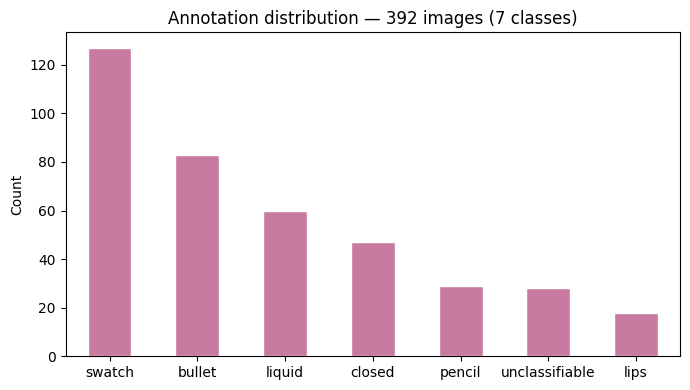

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
labels_df['label'].value_counts().plot(kind='bar', ax=ax, color='#c97aa0', edgecolor='white')
ax.set_title(f'Annotation distribution — {len(labels_df)} images ({len(CLASSES)} classes)')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

We fine-tune a ResNet-18 on the seven annotated container/presentation types (`bullet`, `liquid`, `closed`, `swatch`, `pencil`, `lips`, `unclassifiable`). Training uses two phases: first the backbone is frozen and only the classification head is trained (5 epochs), then the full network is fine-tuned at a lower learning rate (15 epochs). Weighted cross-entropy loss compensates for class imbalance -- `lips` (18) is now the scarcest, well below `pencil` (28), `closed` (39), or `swatch` (123).

**Handling out-of-distribution images:** `unclassifiable` is trained specifically to catch multiple patterns: a fully sealed container with nothing visible, and a photo showing multiple products, a palette, or otherwise not a single clean product shot. That's an explicit, trained catch — a real improvement over the original design, which relied purely on classifier *uncertainty* to catch these cases. Uncertainty isn't a reliable proxy for "doesn't belong to any trained class": a multi-product photo can easily contain something that looks enough like a `bullet` to get a confident, wrong prediction rather than a low-confidence one. The confidence threshold (`CLF_THRESHOLD = 0.6`) is kept as a secondary safety net for images that don't even resemble the `unclassifiable` training examples -- genuinely novel formats not yet seen at all. Both paths lead to the same outcome: no color extracted.

In [8]:
IMG_SIZE_CLS = 224

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_CLS, IMG_SIZE_CLS)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_CLS, IMG_SIZE_CLS)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class ProductDataset(Dataset):
    def __init__(self, df, transform):
        # drop rows where the image can't be found on disk
        self.df = df[df['img_name_disk'].notna()].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(find_image(row['img_name_disk'])).convert('RGB')
        return self.transform(img), CLASSES.index(row['label'])

In [9]:
def build_classifier(num_classes=len(CLASSES), pretrained=True):
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    m = models.resnet18(weights=weights)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

counts = labels_df['label'].value_counts()
total  = len(labels_df)
class_weights = torch.tensor(
    [total / (len(CLASSES) * counts[c]) for c in CLASSES], dtype=torch.float
)
print('Class weights:', {c: round(w, 3) for c, w in zip(CLASSES, class_weights.tolist())})

Class weights: {'bullet': 0.675, 'closed': 1.191, 'lips': 3.111, 'liquid': 0.933, 'pencil': 1.931, 'swatch': 0.441, 'unclassifiable': 2.0}


In [10]:
def run_epoch(model, loader, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            n          += len(y)
    return total_loss / n, correct / n

def train_classifier(model, train_ds, val_ds, device, ckpt_path):
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=32, num_workers=0)

    # Phase 1: freeze backbone
    for p in model.parameters():
        p.requires_grad = False
    for p in model.fc.parameters():
        p.requires_grad = True
    opt = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
    print('Phase 1 — head only (5 epochs)')
    for epoch in range(5):
        _, tr_acc = run_epoch(model, train_loader, criterion, opt, device)
        _, va_acc = run_epoch(model, val_loader,   criterion, opt, device, train=False)
        print(f'  {epoch+1:2d}: train={tr_acc:.3f}  val={va_acc:.3f}')

    # Phase 2: fine-tune all
    for p in model.parameters():
        p.requires_grad = True
    opt = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.1)
    best_val_acc = 0.0
    print('Phase 2 — fine-tune all (15 epochs)')
    for epoch in range(15):
        _, tr_acc = run_epoch(model, train_loader, criterion, opt, device)
        _, va_acc = run_epoch(model, val_loader,   criterion, opt, device, train=False)
        scheduler.step()
        print(f'  {epoch+1:2d}: train={tr_acc:.3f}  val={va_acc:.3f}')
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            torch.save({'model_state_dict': model.state_dict(), 'classes': CLASSES}, ckpt_path)
    print(f'\nBest val acc: {best_val_acc:.3f}  →  {ckpt_path}')

In [11]:
# Split strategy:
# - annotation_sample_closed images (40 oversampled closed class) → always in train
# - everything else → random 80/20 stratified split
ann_closed_files = set(os.listdir(IMG_CLOSED))

force_train = labels_df[labels_df['img_name_disk'].isin(ann_closed_files)]
to_split    = labels_df[~labels_df['img_name_disk'].isin(ann_closed_files) & labels_df['img_name_disk'].notna()]

train_rest, val_df = train_test_split(
    to_split, test_size=0.2, stratify=to_split['label'], random_state=42
)
train_df = pd.concat([force_train, train_rest]).reset_index(drop=True)

print(f'Train: {len(train_df)}  ({len(force_train)} forced closed-addition + {len(train_rest)} random)')
print(f'Val:   {len(val_df)}')
print('\nTrain label distribution:')
print(train_df['label'].value_counts().to_string())
print('\nVal label distribution:')
print(val_df['label'].value_counts().to_string())

seed_everything()
clf = build_classifier(num_classes=len(CLASSES)).to(DEVICE)
clf_ckpt = os.path.join(MODELS_DIR, 'resnet18_classifier.pth')
train_classifier(clf, ProductDataset(train_df, train_tf), ProductDataset(val_df, val_tf), DEVICE, clf_ckpt)

Train: 324  (55 forced closed-addition + 269 random)
Val:   68

Train label distribution:
label
swatch            104
bullet             66
liquid             49
closed             45
pencil             23
unclassifiable     22
lips               15

Val label distribution:
label
swatch            23
bullet            17
liquid            11
pencil             6
unclassifiable     6
lips               3
closed             2


Phase 1 — head only (5 epochs)


   1: train=0.210  val=0.559


   2: train=0.500  val=0.779


   3: train=0.694  val=0.824


...

  11: train=0.997  val=0.941


  12: train=0.997  val=0.941


  13: train=0.997  val=0.941


  14: train=0.997  val=0.941


  15: train=0.997  val=0.941

Best val acc: 0.956  →  /Users/connie/dev/lipstick_color_extraction/models/resnet18_classifier.pth


                precision    recall  f1-score   support

        bullet       0.94      1.00      0.97        17
        closed       0.67      1.00      0.80         2
          lips       1.00      1.00      1.00         3
        liquid       1.00      1.00      1.00        11
        pencil       1.00      0.83      0.91         6
        swatch       0.96      1.00      0.98        23
unclassifiable       1.00      0.67      0.80         6

      accuracy                           0.96        68
     macro avg       0.94      0.93      0.92        68
  weighted avg       0.96      0.96      0.95        68



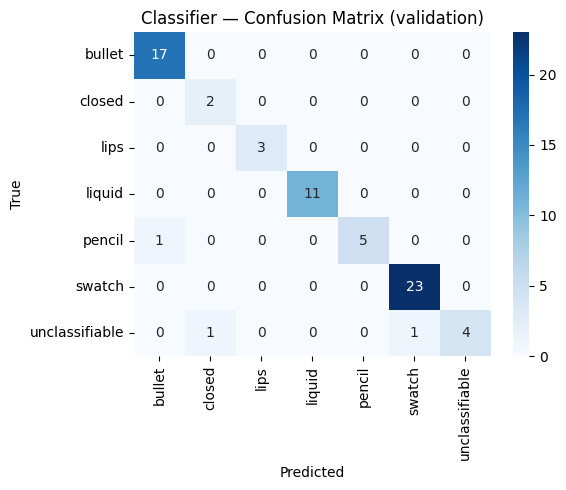

In [12]:
# Load best checkpoint and evaluate on validation set
ckpt = torch.load(clf_ckpt, map_location=DEVICE)
clf.load_state_dict(ckpt['model_state_dict'])
clf.eval()

preds, targets = [], []
with torch.no_grad():
    for x, y in DataLoader(ProductDataset(val_df, val_tf), batch_size=32):
        preds.extend(clf(x.to(DEVICE)).argmax(1).cpu().tolist())
        targets.extend(y.tolist())

print(classification_report(targets, preds, target_names=CLASSES))

cm = confusion_matrix(targets, preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES,
            cmap='Blues', ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Classifier — Confusion Matrix (validation)')
plt.tight_layout(); plt.show()

**Confidence threshold check:** `CLF_THRESHOLD = 0.6` is now a secondary safety net -- `unclassifiable` is a trained class, so most dead-end images should already be routed there directly by the classifier rather than caught by low confidence. The cell below scores all annotated images and shows the ones that would still be caught by this threshold gate -- a face-value sanity check that it's not silently swallowing valid images from the six real product classes.

4 image(s) fall below CLF_THRESHOLD=0.6


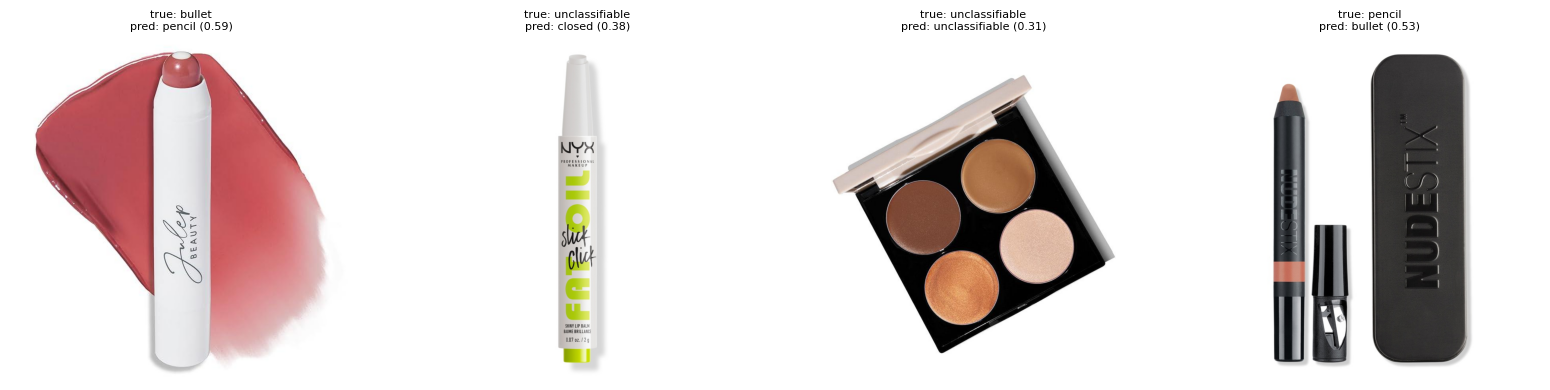

In [13]:
clf.eval()
low_conf = []
for _, row in labels_df.iterrows():
    if pd.isna(row['img_name_disk']):
        continue
    img_path = find_image(row['img_name_disk'])
    if img_path is None:
        continue
    img = Image.open(img_path).convert('RGB')
    with torch.no_grad():
        probs = torch.softmax(clf(val_tf(img).unsqueeze(0).to(DEVICE)), dim=1).squeeze().cpu().numpy()
    conf = float(probs.max())
    if conf < CLF_THRESHOLD:
        low_conf.append({
            'img_path':   img_path,
            'true_label': row['label'],
            'pred_label': CLASSES[probs.argmax()],
            'confidence': conf,
        })

print(f'{len(low_conf)} image(s) fall below CLF_THRESHOLD={CLF_THRESHOLD}')

if low_conf:
    ncols = min(4, len(low_conf))
    nrows = (len(low_conf) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, item in zip(axes, low_conf):
        ax.imshow(Image.open(item['img_path']).convert('RGB'))
        ax.set_title(
            f"true: {item['true_label']}\npred: {item['pred_label']} ({item['confidence']:.2f})",
            fontsize=8
        )
        ax.axis('off')
    for ax in axes[len(low_conf):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


## 3. Stage 2: Color Region Segmenter

Once the classifier assigns a product type, a segmentation model isolates the color-bearing region of the image. We use a U-Net with a ResNet-18 encoder pretrained on ImageNet: the encoder extracts features and the decoder produces a binary mask (1 = color region, 0 = background). All models are trained at 256×256 and evaluated with IoU (Intersection over Union) on a held-out validation split -- a fixed 4-image holdout per class rather than a percentage split, so scarce classes like `lips` don't lose a large share of their already-small training pool to validation, and so the same held-out images power the qualitative mask-comparison plot shown after each stage.

Different product types require different segmenters because their color regions look nothing alike — a bullet tip, a liquid applicator wand, a closed container's visible color through packaging, and a flat swatch each present a distinct segmentation problem. Stage 2a trains a combined segmenter for `bullet`, `liquid`, and `pencil` (a pen/crayon-style applicator tip is visually closer to a bullet tip than to anything else, and it now has enough data (28 images) that it could arguably justify its own model, but stays combined for now since it's still well below `closed` (39) or `bullet`/`liquid` counts). Stage 2b covers `closed` containers; Stage 2c tests whether splitting `bullet` and `liquid` into separate models improves on the combined approach; Stage 2d adds a segmenter for `swatch`; Stage 2e adds a segmenter for `lips` -- originally a 3-example bootstrap with no validation possible at all, now retrained with the same fixed 4-image held-out split now that it has 16 de-duplicated examples.

### Stage 2a: Color Region Segmenter for `bullet`, `liquid`, and `pencil`

In [14]:
IMG_SIZE_SEG = 256

seg_img_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_SEG, IMG_SIZE_SEG)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
seg_mask_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_SEG, IMG_SIZE_SEG),
                      interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor(),
])

SEG_CLASSES = {'bullet', 'liquid', 'pencil'}

class SegDataset(Dataset):
    def __init__(self, df):
        self.df = df[df['label'].isin(SEG_CLASSES) & df['img_name_disk'].notna()
                        & df['mask_path'].apply(os.path.exists)].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = Image.open(find_image(row['img_name_disk'])).convert('RGB')
        mp   = row['mask_path']
        mask = Image.open(mp).convert('L') if os.path.exists(mp) else Image.new('L', img.size, 0)
        return seg_img_tf(img), (seg_mask_tf(mask) > 0.5).float()

In [15]:
def build_segmenter():
    return smp.Unet(
        encoder_name='resnet18',
        encoder_weights='imagenet',
        in_channels=3,
        classes=1,
    )

def batch_iou(logits, masks, threshold=0.5):
    pred = (torch.sigmoid(logits) > threshold).float()
    inter = (pred * masks).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - inter
    return (inter / (union + 1e-6)).mean().item()

In [16]:
seg_eligible = labels_df[labels_df['label'].isin(SEG_CLASSES) & labels_df['img_name_disk'].notna()
                          & labels_df['mask_path'].apply(os.path.exists)]
seg_train_df, seg_val_df = train_test_split(
    seg_eligible, test_size=4, stratify=seg_eligible['label'], random_state=42
)
seed_everything()
seg_train_ds = SegDataset(seg_train_df)
seg_val_ds   = SegDataset(seg_val_df)
print(f'Seg train: {len(seg_train_ds)}  val: {len(seg_val_ds)}')

seg = build_segmenter().to(DEVICE)
criterion_seg = nn.BCEWithLogitsLoss()
opt_seg       = torch.optim.Adam(seg.parameters(), lr=1e-4)
seg_ckpt      = os.path.join(MODELS_DIR, 'unet_segmenter.pth')

best_iou = 0.0
for epoch in range(20):
    seg.train()
    for imgs, masks in DataLoader(seg_train_ds, batch_size=16, shuffle=True, num_workers=0):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        loss = criterion_seg(seg(imgs), masks)
        opt_seg.zero_grad(); loss.backward(); opt_seg.step()

    seg.eval()
    val_ious = []
    with torch.no_grad():
        for imgs, masks in DataLoader(seg_val_ds, batch_size=16, num_workers=0):
            val_ious.append(batch_iou(seg(imgs.to(DEVICE)), masks.to(DEVICE)))
    mean_iou = np.mean(val_ious)
    print(f'epoch {epoch+1:2d}: IoU={mean_iou:.4f}')
    if mean_iou > best_iou:
        best_iou = mean_iou
        torch.save({'model_state_dict': seg.state_dict()}, seg_ckpt)

print(f'\nBest IoU: {best_iou:.4f}  →  {seg_ckpt}')


Seg train: 167  val: 4


epoch  1: IoU=0.0214


epoch  2: IoU=0.0420


epoch  3: IoU=0.0624


epoch  4: IoU=0.0905


...

epoch 16: IoU=0.7655


epoch 17: IoU=0.6496


epoch 18: IoU=0.7340


epoch 19: IoU=0.7846


epoch 20: IoU=0.7482

Best IoU: 0.7846  →  /Users/connie/dev/lipstick_color_extraction/models/unet_segmenter.pth


**Note: scheduler experiment (worse, not used):** Adding `ReduceLROnPlateau` (factor=0.3, patience=5) and extending to 30 epochs produced lower validation IoU than the simple 20-epoch fixed-LR run above. The bottleneck is data size (74 training images), not the learning rate schedule. The path to better segmentation is more annotated images, not longer training.

Visual check on a sample of 4 validation images: original image, hand-drawn Label Studio mask (ground truth), and U-Net prediction side by side. Confirms mask alignment before using predictions for color extraction.

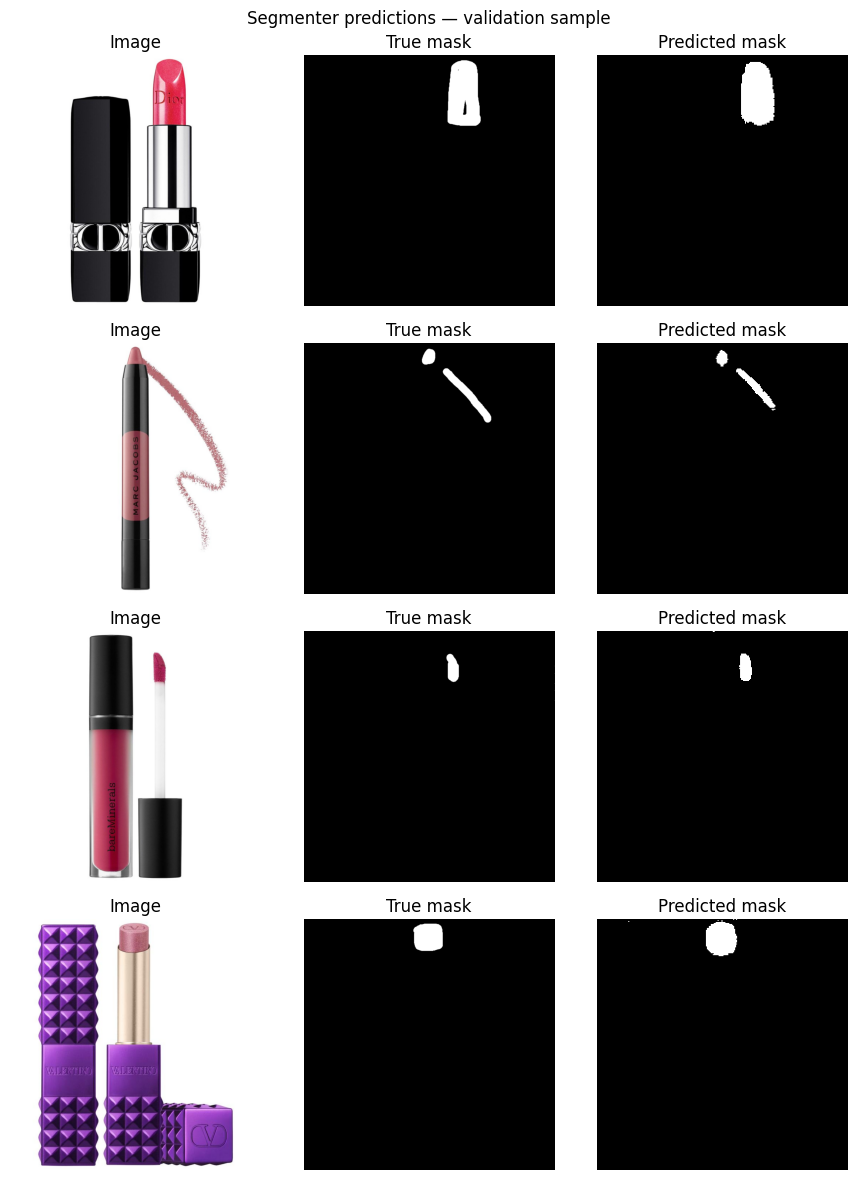

In [17]:
# Visualise a few val predictions
ckpt_seg = torch.load(seg_ckpt, map_location=DEVICE)
seg.load_state_dict(ckpt_seg['model_state_dict'])
seg.eval()

sample = seg_val_df[seg_val_df['img_name_disk'].notna() & seg_val_df['mask_path'].apply(os.path.exists)].head(4).reset_index(drop=True)
fig, axes = plt.subplots(4, 3, figsize=(9, 12))
for i, row in sample.iterrows():
    img_path = find_image(row['img_name_disk'])
    img = Image.open(img_path).convert('RGB')
    x   = seg_img_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_mask = (torch.sigmoid(seg(x)) > 0.5).squeeze().cpu().numpy()
    true_mask = np.array(Image.open(row['mask_path']).convert('L')) if os.path.exists(row['mask_path']) else np.zeros((img.size[1], img.size[0]))
    axes[i, 0].imshow(img); axes[i, 0].set_title('Image')
    axes[i, 1].imshow(true_mask, cmap='gray'); axes[i, 1].set_title('True mask')
    axes[i, 2].imshow(pred_mask, cmap='gray'); axes[i, 2].set_title('Predicted mask')
    for ax in axes[i]: ax.axis('off')
plt.suptitle('Segmenter predictions — validation sample')
plt.tight_layout()
plt.show()

In [18]:
# Shared segmentation helpers, used by the augmentation experiment below and by
# Stages 2b-2d: a dataset that accepts any label subset (with optional
# synchronized image+mask augmentation) and a generic U-Net training loop.
import random

class SegDatasetAny(Dataset):
    """Like SegDataset but accepts any label subset, with optional synchronized
    augmentation. Rows without a real drawn mask are excluded, not padded with a
    blank one -- a blank mask would wrongly teach the model 'no color here' for an
    unannotated image that may well have a visible color region."""
    def __init__(self, df, augment=False):
        self.df      = df[df['img_name_disk'].notna()
                        & df['mask_path'].apply(os.path.exists)].reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = Image.open(find_image(row['img_name_disk'])).convert('RGB')
        mp   = row['mask_path']
        mask = Image.open(mp).convert('L') if os.path.exists(mp) else Image.new('L', img.size, 0)

        if self.augment:
            if random.random() > 0.5:
                img  = img.transpose(Image.FLIP_LEFT_RIGHT)
                mask = mask.transpose(Image.FLIP_LEFT_RIGHT)
            if random.random() > 0.5:
                img  = img.transpose(Image.FLIP_TOP_BOTTOM)
                mask = mask.transpose(Image.FLIP_TOP_BOTTOM)
            angle = random.uniform(-15, 15)
            img  = img.rotate(angle)
            mask = mask.rotate(angle)

        return seg_img_tf(img), (seg_mask_tf(mask) > 0.5).float()

def train_seg_model(train_df, val_df, ckpt_path, n_epochs=20, augment=False):
    train_ds = SegDatasetAny(train_df, augment=augment)
    val_ds   = SegDatasetAny(val_df,   augment=False)
    model    = build_segmenter().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    opt       = torch.optim.Adam(model.parameters(), lr=1e-4)
    best_iou  = 0.0
    for epoch in range(n_epochs):
        model.train()
        for imgs, masks in DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            loss = criterion(model(imgs), masks)
            opt.zero_grad(); loss.backward(); opt.step()
        model.eval()
        val_ious = []
        with torch.no_grad():
            for imgs, masks in DataLoader(val_ds, batch_size=16, num_workers=0):
                val_ious.append(batch_iou(model(imgs.to(DEVICE)), masks.to(DEVICE)))
        mean_iou = np.mean(val_ious)
        print(f'  epoch {epoch+1:2d}: IoU={mean_iou:.4f}')
        if mean_iou > best_iou:
            best_iou = mean_iou
            torch.save({'model_state_dict': model.state_dict()}, ckpt_path)
    print(f'Best IoU: {best_iou:.4f}  →  {ckpt_path}')
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE)['model_state_dict'])
    model.eval()
    return model, best_iou

**Augmentation experiment:** The baseline above (Stage 2a, now trained on 167 of 171 eligible images after switching to a fixed 4-image validation holdout instead of an 80/20 split) reached IoU 0.7846. Re-running with synchronized augmentation (random horizontal flips + small rotations) and 60 epochs reached IoU 0.8016 -- again a real improvement over baseline, consistent with earlier rounds. (Note: Python's `random` module isn't seeded like `numpy`/`torch` are, so the augmented run's exact IoU drifts between re-runs of this notebook. The qualitative conclusion, augmentation helps, has held every time so far.)

**Not yet adopted downstream:** routing, the strategy comparison, and the end-to-end evaluation below still use the non-augmented `seg` checkpoint (`unet_segmenter.pth`), matching the original Stage 2a design. Given the result flipped, switching production to `unet_seg_augmented.pth` is worth revisiting, but that's a separate decision from the class-taxonomy change this notebook update was about.

In [19]:
seed_everything()
seg_aug_ckpt = os.path.join(MODELS_DIR, 'unet_seg_augmented.pth')
seg_aug, iou_aug = train_seg_model(
    seg_train_df, seg_val_df, seg_aug_ckpt, n_epochs=60, augment=True
)
print(f'Baseline IoU: {best_iou:.4f}  →  Augmented IoU: {iou_aug:.4f}')

  epoch  1: IoU=0.0211


  epoch  2: IoU=0.0316


  epoch  3: IoU=0.0530


  epoch  4: IoU=0.0771


  epoch  5: IoU=0.1077


...

  epoch 56: IoU=0.7796


  epoch 57: IoU=0.7780


  epoch 58: IoU=0.7754


  epoch 59: IoU=0.7495


  epoch 60: IoU=0.6838
Best IoU: 0.8016  →  /Users/connie/dev/lipstick_color_extraction/models/unet_seg_augmented.pth
Baseline IoU: 0.7846  →  Augmented IoU: 0.8016


### Stage 2b: Color Region Segmenter for `closed` (Transparent Containers)

`closed` images (transparent containers) have hand-drawn masks highlighting the visible color through the packaging: the same annotation format as bullet/liquid. A separate U-Net is trained on these images so color can be extracted the same way as the other classes.

Same architecture and training procedure as Stage 2a; saved to `models/unet_segmenter_other.pth`.

In [20]:
other_df = labels_df[(labels_df['label'] == 'closed') & labels_df['img_name_disk'].notna()
                      & labels_df['mask_path'].apply(os.path.exists)].reset_index(drop=True)
seg_other_train_df, seg_other_val_df = train_test_split(
    other_df, test_size=4, random_state=42
)
seed_everything()
seg_other_train_ds = SegDatasetAny(seg_other_train_df, augment=True)
seg_other_val_ds   = SegDatasetAny(seg_other_val_df,   augment=False)
print(f'Other seg — train: {len(seg_other_train_ds)}  val: {len(seg_other_val_ds)}')

# Warm-start from bullet/liquid segmenter — encoder + decoder already tuned to lipstick images
seg_other = build_segmenter().to(DEVICE)
seg_other.load_state_dict(torch.load(seg_ckpt, map_location=DEVICE)['model_state_dict'])
print('Warm-started from unet_segmenter.pth')

crit_seg_other = nn.BCEWithLogitsLoss()
opt_seg_other  = torch.optim.Adam(seg_other.parameters(), lr=1e-4)
seg_other_ckpt = os.path.join(MODELS_DIR, 'unet_segmenter_other.pth')

best_iou_other = 0.0
for epoch in range(20):
    seg_other.train()
    for imgs, masks in DataLoader(seg_other_train_ds, batch_size=16, shuffle=True, num_workers=0):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        loss = crit_seg_other(seg_other(imgs), masks)
        opt_seg_other.zero_grad(); loss.backward(); opt_seg_other.step()

    seg_other.eval()
    val_ious = []
    with torch.no_grad():
        for imgs, masks in DataLoader(seg_other_val_ds, batch_size=16, num_workers=0):
            val_ious.append(batch_iou(seg_other(imgs.to(DEVICE)), masks.to(DEVICE)))
    mean_iou = np.mean(val_ious)
    print(f'epoch {epoch+1:2d}: IoU={mean_iou:.4f}')
    if mean_iou > best_iou_other:
        best_iou_other = mean_iou
        torch.save({'model_state_dict': seg_other.state_dict()}, seg_other_ckpt)

print(f'\nBest IoU: {best_iou_other:.4f}  →  {seg_other_ckpt}')

ckpt_seg_other = torch.load(seg_other_ckpt, map_location=DEVICE)
seg_other.load_state_dict(ckpt_seg_other['model_state_dict'])
seg_other.eval()
print('seg_other loaded from best checkpoint')

Other seg — train: 35  val: 4


Warm-started from unet_segmenter.pth


epoch  1: IoU=0.1017


epoch  2: IoU=0.6742


epoch  3: IoU=0.6718


...

epoch 16: IoU=0.7966


epoch 17: IoU=0.8163


epoch 18: IoU=0.8151


epoch 19: IoU=0.8243


epoch 20: IoU=0.8285

Best IoU: 0.8430  →  /Users/connie/dev/lipstick_color_extraction/models/unet_segmenter_other.pth
seg_other loaded from best checkpoint


Initial training on `closed` images (ImageNet weights, no augmentation) produced loose, imprecise masks: the model found the general region but failed to follow the color boundary tightly. Two changes improved this:

1. **Warm start from `unet_segmenter.pth`**: instead of starting from generic ImageNet weights, the model is initialized with the bullet/liquid segmenter's weights. Both encoder and decoder have already learned what a lipstick color-region mask looks like, giving a much better starting point.
2. **Synchronized augmentation**: horizontal flip, vertical flip, and ±15° rotation are applied identically to the image and mask during training. With only 35 training images, this significantly increases the effective diversity seen by the model.

The validation sample below shows the predicted mask aligning tightly with the ground-truth mask after these changes.

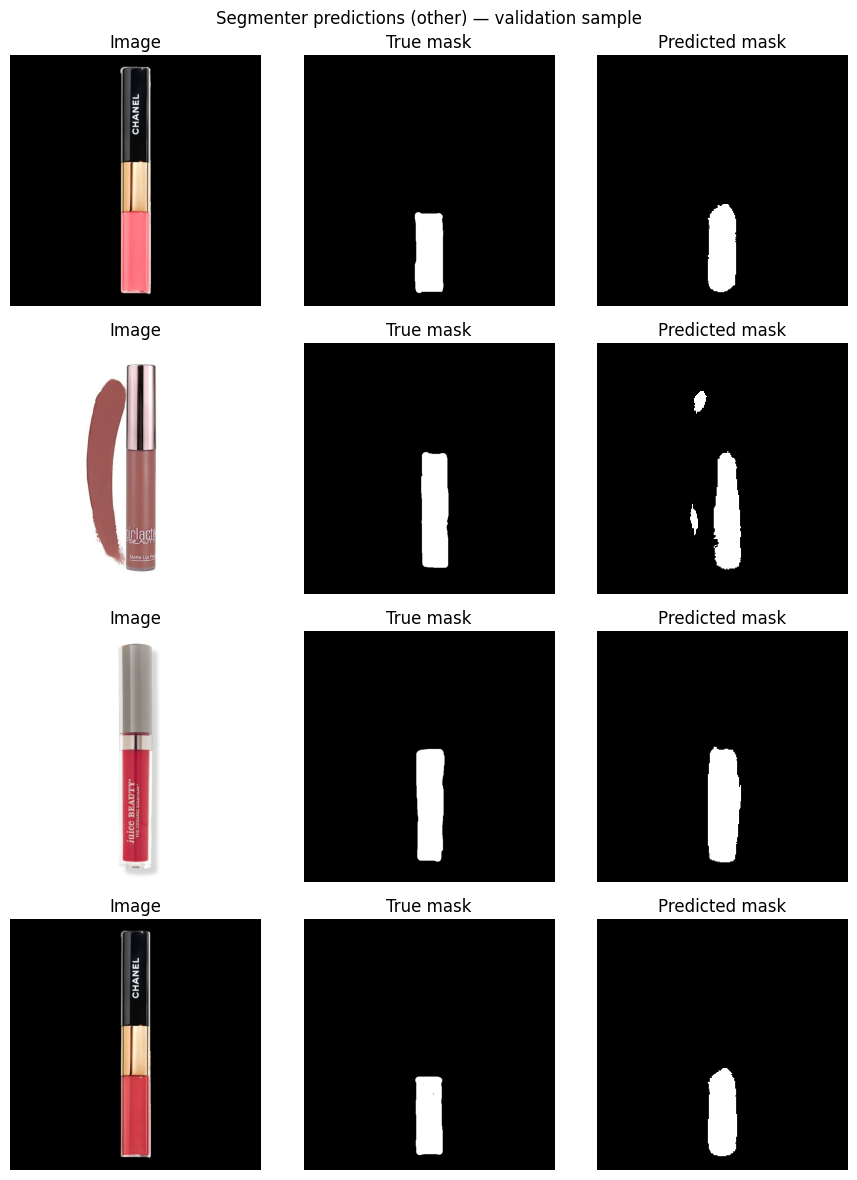

In [21]:
sample_other = seg_other_val_df[seg_other_val_df['img_name_disk'].notna() & seg_other_val_df['mask_path'].apply(os.path.exists)].reset_index(drop=True)
fig, axes = plt.subplots(len(sample_other), 3, figsize=(9, 3 * len(sample_other)))
axes = np.array(axes).reshape(len(sample_other), 3)
for i, row in sample_other.iterrows():
    img_path = find_image(row['img_name_disk'])
    img = Image.open(img_path).convert('RGB')
    x   = seg_img_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_mask = (torch.sigmoid(seg_other(x)) > 0.5).squeeze().cpu().numpy()
    true_mask = np.array(Image.open(row['mask_path']).convert('L')) if os.path.exists(row['mask_path']) else np.zeros((img.size[1], img.size[0]))
    axes[i, 0].imshow(img); axes[i, 0].set_title('Image')
    axes[i, 1].imshow(true_mask, cmap='gray'); axes[i, 1].set_title('True mask')
    axes[i, 2].imshow(pred_mask, cmap='gray'); axes[i, 2].set_title('Predicted mask')
    for ax in axes[i]: ax.axis('off')
plt.suptitle('Segmenter predictions (other) — validation sample')
plt.tight_layout()
plt.show()

### Stage 2c: Separate Segmenters for `bullet` vs `liquid`

Two paths for segmenting bullet and liquid lipsticks:

- **Combined (Stage 2a):** One U-Net trained on all `bullet` + `liquid` + `pencil` images (171 total, 167 train after the fixed 4-image holdout). More training data, simpler to maintain. Risk: the model must learn several visually distinct mask patterns simultaneously — an extended bullet tip, a doe-foot applicator wand, a pencil tip.
- **Separate (this section):** One U-Net per type, `bullet` vs `liquid` only (66 bullet train, 48 liquid train, still an 80/20 split here since this comparison wants a larger, statistically meaningful held-out set rather than the minimal 4-image holdout used for the production segmenters; `pencil` now has 27 examples -- enough that it could be tested separately, but isn't here since this comparison predates that growth and the conclusion below doesn't depend on it). Each model only sees one pattern, which may produce tighter masks. Trade-off: fewer training examples each.

The cells below train two separate models and compare their validation IoU against the combined model to see which approach generalises better.

In [22]:
bullet_df = labels_df[(labels_df['label'] == 'bullet') & labels_df['img_name_disk'].notna()]
liquid_df = labels_df[(labels_df['label'] == 'liquid') & labels_df['img_name_disk'].notna()]

bullet_train_df, bullet_val_df = train_test_split(bullet_df, test_size=0.2, random_state=42)
liquid_train_df, liquid_val_df = train_test_split(liquid_df, test_size=0.2, random_state=42)

print(f'Bullet — train: {len(bullet_train_df)}  val: {len(bullet_val_df)}')
print(f'Liquid — train: {len(liquid_train_df)}  val: {len(liquid_val_df)}')

bullet_ckpt = os.path.join(MODELS_DIR, 'unet_bullet.pth')
liquid_ckpt = os.path.join(MODELS_DIR, 'unet_liquid.pth')

seed_everything()
print('Training bullet segmenter...')
seg_bullet, iou_bullet = train_seg_model(bullet_train_df, bullet_val_df, bullet_ckpt)

print('\nTraining liquid segmenter...')
seg_liquid, iou_liquid = train_seg_model(liquid_train_df, liquid_val_df, liquid_ckpt)


Bullet — train: 66  val: 17
Liquid — train: 48  val: 12
Training bullet segmenter...


  epoch  1: IoU=0.0165


  epoch  2: IoU=0.0283


  epoch  3: IoU=0.0462


  epoch  4: IoU=0.0607


...

  epoch 16: IoU=0.0906


  epoch 17: IoU=0.1199


  epoch 18: IoU=0.1514


  epoch 19: IoU=0.1923


  epoch 20: IoU=0.2399
Best IoU: 0.2399  →  /Users/connie/dev/lipstick_color_extraction/models/unet_liquid.pth


In [23]:
def eval_iou(model, df):
    ds = SegDatasetAny(df)
    model.eval()
    ious = []
    with torch.no_grad():
        for imgs, masks in DataLoader(ds, batch_size=16, num_workers=0):
            ious.append(batch_iou(model(imgs.to(DEVICE)), masks.to(DEVICE)))
    return np.mean(ious)

iou_combined_bullet = eval_iou(seg, bullet_val_df)
iou_combined_liquid = eval_iou(seg, liquid_val_df)
iou_combined_all    = eval_iou(seg, pd.concat([bullet_val_df, liquid_val_df]))

print('Validation IoU — combined vs separate segmenters\n')
print(f'{"":20} {"combined":>10} {"separate":>10}')
print(f'{"bullet":20} {iou_combined_bullet:>10.4f} {iou_bullet:>10.4f}')
print(f'{"liquid":20} {iou_combined_liquid:>10.4f} {iou_liquid:>10.4f}')
print(f'{"overall":20} {iou_combined_all:>10.4f} {(iou_bullet + iou_liquid) / 2:>10.4f}')

Validation IoU — combined vs separate segmenters

                       combined   separate
bullet                   0.9008     0.5505
liquid                   0.7793     0.2399
overall                  0.8425     0.3952


Splitting into separate models still hurt performance -- combined overall IoU 0.84 vs. separate 0.40 this run. The liquid segmenter alone collapsed (0.24 IoU standalone, vs. the combined model's 0.78 on the same images) and the bullet segmenter alone (0.55) trails the combined model's 0.90 by a similar margin. The exact numbers drift between re-runs -- both from the unseeded augmentation randomness noted in Stage 2a and from the combined model now training on more data after the switch to a fixed 4-image holdout -- but the qualitative conclusion has held every round: the combined model's advantage isn't just about having more data in aggregate, but also that seeing multiple mask patterns together helps the model learn a more robust "foreground lipstick vs background" representation. At this dataset size, data volume still matters more than pattern specialization, so the combined segmenter from Stage 2a is what gets used downstream.

### Stage 2d: Color Region Segmenter for `swatch`

It is unclear whether swatches require full segmentation or whether a simpler approach — such as filtering pixels by lightness threshold — would be sufficient for accurate color extraction. To establish a benchmark and keep the pipeline consistent across product types, we train a U-Net segmenter on 119 of 123 annotated swatch images (a fixed 4-image holdout, same as the other segmenters) using the same architecture as Stage 2a.

**Improving segmentation quality:** An initial run without augmentation reached IoU 0.9049 at epoch 20. To push further, we added synchronized augmentation (random horizontal flips and small rotations applied identically to the image and mask) and extended training to 40 epochs. This brought IoU to **0.9348** (varies a couple points run to run, see the augmentation note in Stage 2a) — augmentation helped the model generalise across the varied backgrounds and orientations common in swatch photos.

In [24]:
swatch_df = labels_df[(labels_df['label'] == 'swatch') & labels_df['img_name_disk'].notna()
                       & labels_df['mask_path'].apply(os.path.exists)]
swatch_train_df, swatch_val_df = train_test_split(swatch_df, test_size=4, random_state=42)
print(f'Swatch seg — train: {len(swatch_train_df)}  val: {len(swatch_val_df)}')

seed_everything()
swatch_ckpt = os.path.join(MODELS_DIR, 'unet_swatch.pth')
seg_swatch, iou_swatch = train_seg_model(
    swatch_train_df, swatch_val_df, swatch_ckpt, n_epochs=40, augment=True
)


Swatch seg — train: 119  val: 4


  epoch  1: IoU=0.3262


  epoch  2: IoU=0.4743


  epoch  3: IoU=0.6306


  epoch  4: IoU=0.7306


...

  epoch 36: IoU=0.9243


  epoch 37: IoU=0.9303


  epoch 38: IoU=0.9282


  epoch 39: IoU=0.9297


  epoch 40: IoU=0.9329
Best IoU: 0.9348  →  /Users/connie/dev/lipstick_color_extraction/models/unet_swatch.pth


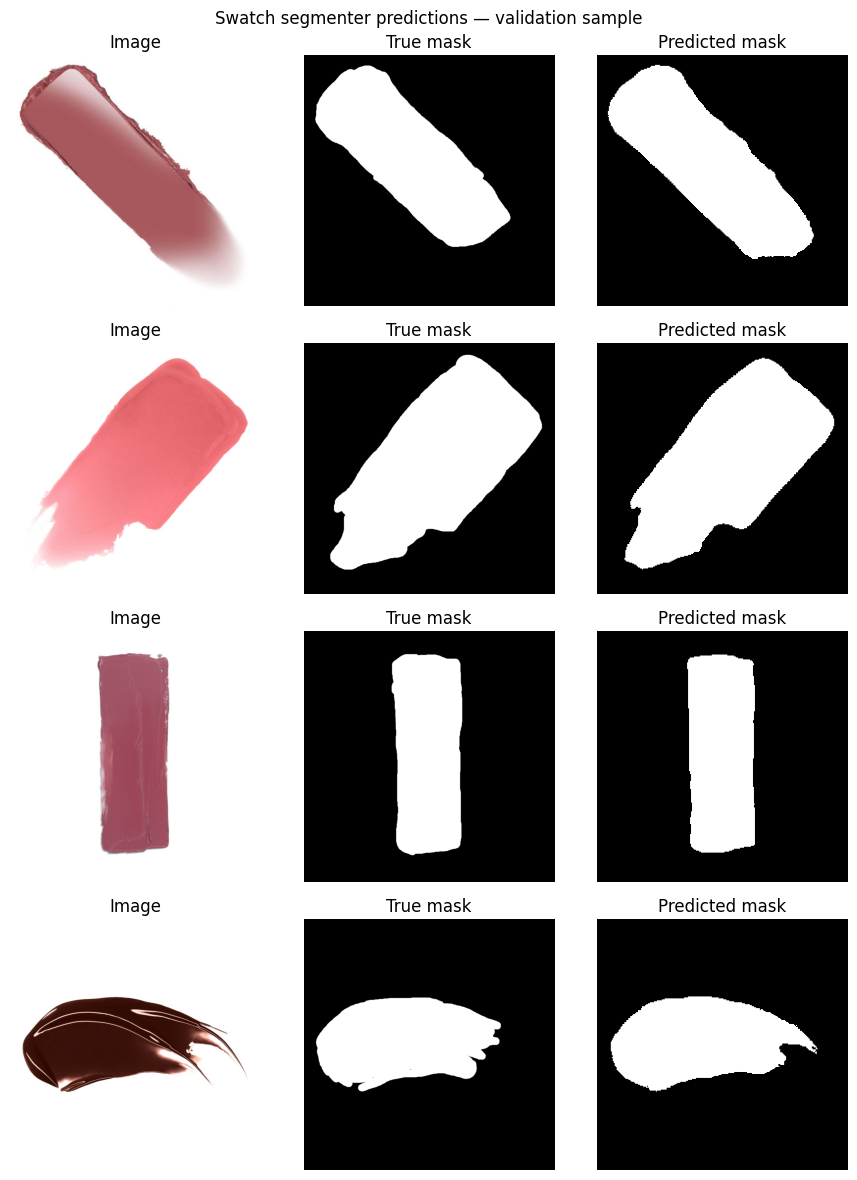

In [25]:
sample_swatch = swatch_val_df[swatch_val_df['img_name_disk'].notna() & swatch_val_df['mask_path'].apply(os.path.exists)].head(4).reset_index(drop=True)
fig, axes = plt.subplots(4, 3, figsize=(9, 12))
for i, row in sample_swatch.iterrows():
    img = Image.open(find_image(row['img_name_disk'])).convert('RGB')
    x   = seg_img_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_mask = (torch.sigmoid(seg_swatch(x)) > 0.5).squeeze().cpu().numpy()
    true_mask = np.array(Image.open(row['mask_path']).convert('L')) if os.path.exists(row['mask_path']) else np.zeros((img.size[1], img.size[0]))
    axes[i, 0].imshow(img); axes[i, 0].set_title('Image')
    axes[i, 1].imshow(true_mask, cmap='gray'); axes[i, 1].set_title('True mask')
    axes[i, 2].imshow(pred_mask, cmap='gray'); axes[i, 2].set_title('Predicted mask')
    for ax in axes[i]: ax.axis('off')
plt.suptitle('Swatch segmenter predictions — validation sample')
plt.tight_layout()
plt.show()

### Stage 2e: Color Region Segmenter for `lips`

`lips` started Round 3 with 3 examples -- too few for any train/val split, so the first version of this model force-trained on all 3 with no way to measure real quality. Round 4's oversampling brought it to 19 labeled; Round 5 then corrected one mislabeled image (task 332, a swatch photo of a lip-tint product) from `lips` back to `pencil`, leaving 18 labeled, 16 unique after de-duplicating shared retailer photos -- enough for a fixed 4-image held-out split (the same minimal holdout now used across all four segmenters, chosen so a scarce class like this one doesn't lose a large share of its training pool to validation), the same point `closed` was upgraded from a force-trained bootstrap to a validated model. Still warm-started from the combined `bullet`/`liquid`/`pencil` segmenter, same trick Stage 2b used for `closed`.

In [26]:
lips_df = labels_df[(labels_df['label'] == 'lips') & labels_df['img_name_disk'].notna()
                     & labels_df['mask_path'].apply(os.path.exists)].reset_index(drop=True)

# A handful of catalog rows share one retailer photo across multiple shade
# listings (seen elsewhere in this catalog too -- see the L'Oreal writeup).
# With only 18 lips images total, a duplicate wastes a training slot, and if
# both copies land in the 4-image val split, one image's score gets counted
# twice. De-duplicate by image content before splitting.
def _content_hash(img_name):
    with open(find_image(img_name), 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()
n_before_dedup = len(lips_df)
lips_df = (lips_df.assign(_hash=lips_df['img_name_disk'].apply(_content_hash))
                   .drop_duplicates(subset='_hash')
                   .drop(columns='_hash')
                   .reset_index(drop=True))
print(f'lips images available: {len(lips_df)} (deduplicated from {n_before_dedup}; some rows share one retailer photo)')

lips_train_df, lips_val_df = train_test_split(lips_df, test_size=4, random_state=42)
print(f'Lips seg -- train: {len(lips_train_df)}  val: {len(lips_val_df)}')

seed_everything()
lips_ckpt = os.path.join(MODELS_DIR, 'unet_lips.pth')

# Warm-started from the combined bullet/liquid/pencil segmenter, same trick Stage 2b used for `closed`.
seg_lips = build_segmenter().to(DEVICE)
seg_lips.load_state_dict(torch.load(seg_ckpt, map_location=DEVICE)['model_state_dict'])
print('Warm-started from unet_segmenter.pth')

crit_lips = nn.BCEWithLogitsLoss()
opt_lips  = torch.optim.Adam(seg_lips.parameters(), lr=1e-4)
lips_train_ds = SegDatasetAny(lips_train_df, augment=True)
lips_val_ds   = SegDatasetAny(lips_val_df,   augment=False)

best_iou_lips = 0.0
for epoch in range(30):
    seg_lips.train()
    for imgs, masks in DataLoader(lips_train_ds, batch_size=8, shuffle=True, num_workers=0):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        loss = crit_lips(seg_lips(imgs), masks)
        opt_lips.zero_grad(); loss.backward(); opt_lips.step()

    seg_lips.eval()
    with torch.no_grad():
        val_ious = []
        for imgs, masks in DataLoader(lips_val_ds, batch_size=8, num_workers=0):
            val_ious.append(batch_iou(seg_lips(imgs.to(DEVICE)), masks.to(DEVICE)))
        mean_iou = np.mean(val_ious)
    print(f'epoch {epoch+1:2d}: IoU={mean_iou:.4f}')
    if mean_iou > best_iou_lips:
        best_iou_lips = mean_iou
        torch.save({'model_state_dict': seg_lips.state_dict()}, lips_ckpt)

print(f'\nBest IoU: {best_iou_lips:.4f}  ->  {lips_ckpt}')

ckpt_lips = torch.load(lips_ckpt, map_location=DEVICE)
seg_lips.load_state_dict(ckpt_lips['model_state_dict'])
seg_lips.eval()
print('seg_lips loaded from best checkpoint')

lips images available: 16 (deduplicated from 18; some rows share one retailer photo)
Lips seg -- train: 12  val: 4


Warm-started from unet_segmenter.pth


epoch  1: IoU=0.0839


epoch  2: IoU=0.3070


epoch  3: IoU=0.3920


...

epoch 26: IoU=0.3493


epoch 27: IoU=0.3607


epoch 28: IoU=0.4280


epoch 29: IoU=0.4506


epoch 30: IoU=0.4496

Best IoU: 0.4506  ->  /Users/connie/dev/lipstick_color_extraction/models/unet_lips.pth
seg_lips loaded from best checkpoint


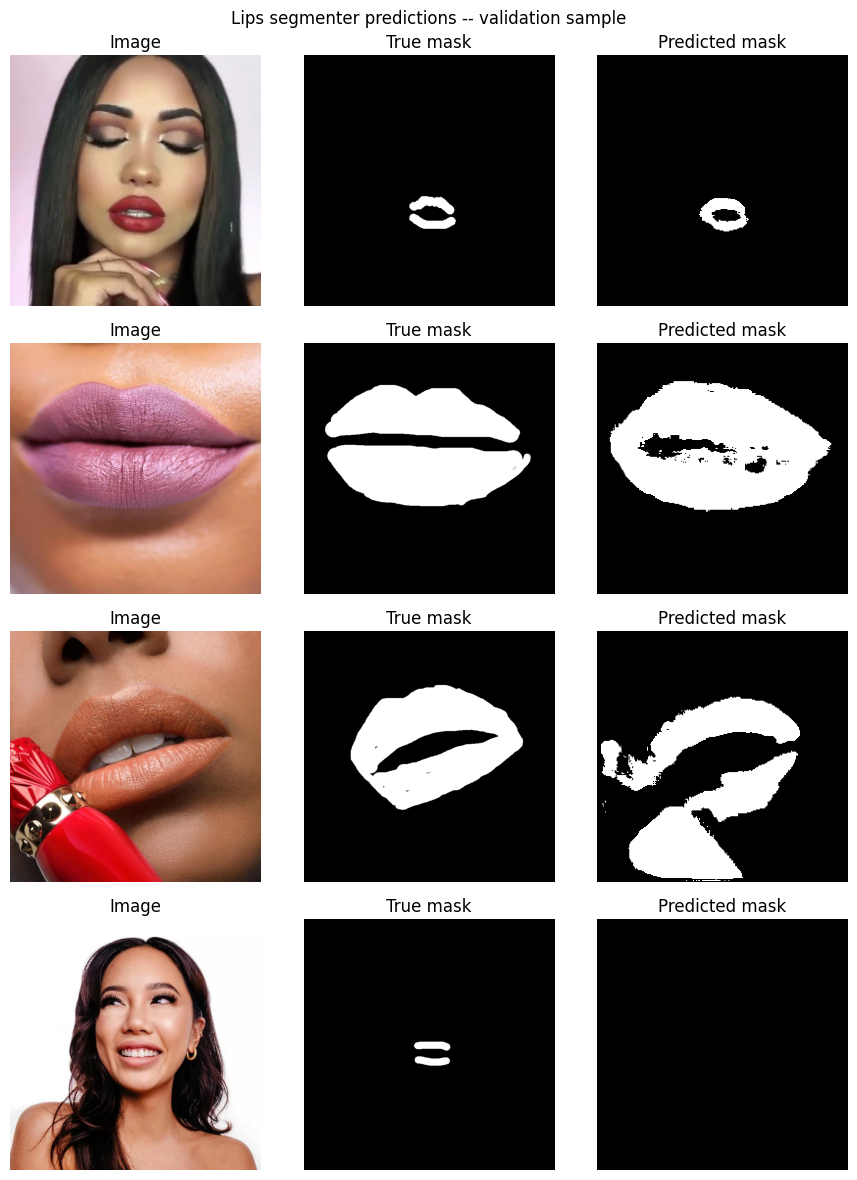

In [27]:
sample_lips = lips_val_df[lips_val_df['img_name_disk'].notna() & lips_val_df['mask_path'].apply(os.path.exists)].reset_index(drop=True)
fig, axes = plt.subplots(len(sample_lips), 3, figsize=(9, 3 * len(sample_lips)))
axes = np.array(axes).reshape(len(sample_lips), 3)
for i, row in sample_lips.iterrows():
    img_path = find_image(row['img_name_disk'])
    img = Image.open(img_path).convert('RGB')
    x   = seg_img_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_mask = (torch.sigmoid(seg_lips(x)) > 0.5).squeeze().cpu().numpy()
    true_mask = np.array(Image.open(row['mask_path']).convert('L')) if os.path.exists(row['mask_path']) else np.zeros((img.size[1], img.size[0]))
    axes[i, 0].imshow(img); axes[i, 0].set_title('Image')
    axes[i, 1].imshow(true_mask, cmap='gray'); axes[i, 1].set_title('True mask')
    axes[i, 2].imshow(pred_mask, cmap='gray'); axes[i, 2].set_title('Predicted mask')
    for ax in axes[i]: ax.axis('off')
plt.suptitle('Lips segmenter predictions -- validation sample')
plt.tight_layout()
plt.show()